# Visualization of Train Datasets from Data Preparation Pipelines

This notebook visualizes the three train datasets produced by the data preparation pipelines:
- **Pipeline 1**: Missing Data Preservation (no imputation)
- **Pipeline 2**: Median/Mode Imputation (with missingness indicators)
- **Pipeline 3**: MICE Imputation (with missingness indicators)

We'll examine data distributions, missing values, feature correlations, and target variable characteristics.

## Setup: Import Libraries and Load Data

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


In [62]:
# Define paths - prepared_datasets is in the same directory as this notebook
current_dir = Path.cwd()
prepared_dir = current_dir / 'prepared_datasets'

# If not found, try one level up (in case running from parent directory)
if not prepared_dir.exists():
    prepared_dir = current_dir.parent / 'prepared_datasets'

# If still not found, try from the Data-prepare directory specifically
if not prepared_dir.exists():
    prepared_dir = Path(__file__).parent / 'prepared_datasets' if '__file__' in dir() else current_dir / 'prepared_datasets'

print(f"Current directory: {current_dir}")
print(f"Prepared datasets directory: {prepared_dir}")
print(f"Directory exists: {prepared_dir.exists()}")

if not prepared_dir.exists():
    print(f"\n⚠️  Warning: Directory not found at {prepared_dir}")
    print(f"Searching for prepared_datasets directory...")
    # Search up the directory tree
    search_dir = current_dir
    for i in range(5):  # Search up to 5 levels
        test_dir = search_dir / 'prepared_datasets'
        if test_dir.exists():
            prepared_dir = test_dir
            print(f"✓ Found at: {prepared_dir}")
            break
        search_dir = search_dir.parent


Current directory: c:\Users\GinoH\OneDrive - SGB SMIT Group\Documents\GitHub\EAISI-NHS\notebooks\Lalita\UnderstandingData\Data-prepare
Prepared datasets directory: c:\Users\GinoH\OneDrive - SGB SMIT Group\Documents\GitHub\EAISI-NHS\notebooks\Lalita\UnderstandingData\Data-prepare\prepared_datasets
Directory exists: True


In [63]:
# Load all train and target data
print("Loading datasets...\n")

if not prepared_dir.exists():
    print(f"❌ ERROR: prepared_datasets directory not found at {prepared_dir}")
    print(f"Available files in {current_dir}:")
    for item in sorted(current_dir.iterdir()):
        print(f"  {item.name}")
else:
    print(f"✓ Found prepared_datasets at: {prepared_dir}\n")
    
    # List available files
    available_files = list(prepared_dir.glob('*.parquet'))
    print(f"Available parquet files: {len(available_files)}")
    for f in sorted(available_files)[:5]:
        print(f"  - {f.name}")
    if len(available_files) > 5:
        print(f"  ... and {len(available_files) - 5} more")
    print()

# Pipeline 1: Missing Data Preservation
p1_features_file = prepared_dir / 'pipeline1_missing_train.parquet'
p1_target_file = prepared_dir / 'pipeline1_missing_train_target.parquet'

# Pipeline 2: Median/Mode Imputation
p2_features_file = prepared_dir / 'pipeline2_median_mode_train.parquet'
p2_target_file = prepared_dir / 'pipeline2_median_mode_train_target.parquet'

# Pipeline 3: MICE Imputation
p3_features_file = prepared_dir / 'pipeline3_mice_train.parquet'
p3_target_file = prepared_dir / 'pipeline3_mice_train_target.parquet'

# Check if files exist
missing_files = []
for f in [p1_features_file, p1_target_file, p2_features_file, p2_target_file, p3_features_file, p3_target_file]:
    if not f.exists():
        missing_files.append(f.name)

if missing_files:
    print(f"❌ ERROR: Missing files:")
    for f in missing_files:
        print(f"  - {f}")
    print(f"\n⚠️  Please run the data preparation notebook first to generate these files.")
else:
    print("✓ All required files found\n")
    
    X_train_p1 = pd.read_parquet(p1_features_file)
    y_train_p1 = pd.read_parquet(p1_target_file).squeeze()

    X_train_p2 = pd.read_parquet(p2_features_file)
    y_train_p2 = pd.read_parquet(p2_target_file).squeeze()

    X_train_p3 = pd.read_parquet(p3_features_file)
    y_train_p3 = pd.read_parquet(p3_target_file).squeeze()

    print("✓ All datasets loaded successfully")
    print(f"\nPipeline 1 - Missing Data Preservation:")
    print(f"  Features: {X_train_p1.shape}")
    print(f"  Target: {y_train_p1.shape}")

    print(f"\nPipeline 2 - Median/Mode Imputation:")
    print(f"  Features: {X_train_p2.shape}")
    print(f"  Target: {y_train_p2.shape}")

    print(f"\nPipeline 3 - MICE Imputation:")
    print(f"  Features: {X_train_p3.shape}")
    print(f"  Target: {y_train_p3.shape}")


Loading datasets...

✓ Found prepared_datasets at: c:\Users\GinoH\OneDrive - SGB SMIT Group\Documents\GitHub\EAISI-NHS\notebooks\Lalita\UnderstandingData\Data-prepare\prepared_datasets

Available parquet files: 12
  - pipeline1_missing_test.parquet
  - pipeline1_missing_test_target.parquet
  - pipeline1_missing_train.parquet
  - pipeline1_missing_train_target.parquet
  - pipeline2_median_mode_test.parquet
  ... and 7 more

✓ All required files found

✓ All datasets loaded successfully

Pipeline 1 - Missing Data Preservation:
  Features: (108040, 45)
  Target: (108040,)

Pipeline 2 - Median/Mode Imputation:
  Features: (108040, 50)
  Target: (108040,)

Pipeline 3 - MICE Imputation:
  Features: (108040, 50)
  Target: (108040,)


In [80]:
X_train_p3.columns

Index(['Provider Code', 'Procedure', 'Revision Flag', 'Year', 'Age Band',
       'Gender', 'Pre-Op Q Assisted', 'Pre-Op Q Assisted By',
       'Pre-Op Q Symptom Period', 'Pre-Op Q Previous Surgery',
       'Pre-Op Q Living Arrangements', 'Pre-Op Q Disability', 'Heart Disease',
       'High Bp', 'Stroke', 'Circulation', 'Lung Disease', 'Diabetes',
       'Kidney Disease', 'Nervous System', 'Liver Disease', 'Cancer',
       'Depression', 'Arthritis', 'Pre-Op Q Mobility', 'Pre-Op Q Self-Care',
       'Pre-Op Q Activity', 'Pre-Op Q Discomfort', 'Pre-Op Q Anxiety',
       'Pre-Op Q EQ5D Index Profile', 'Pre-Op Q EQ5D Index', 'Pre-Op Q EQ VAS',
       'Knee Replacement Pre-Op Q Pain',
       'Knee Replacement Pre-Op Q Night Pain',
       'Knee Replacement Pre-Op Q Washing',
       'Knee Replacement Pre-Op Q Transport',
       'Knee Replacement Pre-Op Q Walking',
       'Knee Replacement Pre-Op Q Standing',
       'Knee Replacement Pre-Op Q Limping',
       'Knee Replacement Pre-Op Q Kneeling

## 1. Target Variable Comparison

In [65]:
# Summary statistics for target variables
print("="*70)
print("TARGET VARIABLE: Q-Score Difference (Post-Op - Pre-Op)")
print("="*70)

target_stats = pd.DataFrame({
    'Pipeline 1': y_train_p1.describe(),
    'Pipeline 2': y_train_p2.describe(),
    'Pipeline 3': y_train_p3.describe()
})

print("\n" + target_stats.to_string())

print(f"\nMissing values:")
print(f"  Pipeline 1: {y_train_p1.isnull().sum()}")
print(f"  Pipeline 2: {y_train_p2.isnull().sum()}")
print(f"  Pipeline 3: {y_train_p3.isnull().sum()}")

TARGET VARIABLE: Q-Score Difference (Post-Op - Pre-Op)

          Pipeline 1     Pipeline 2     Pipeline 3
count  108040.000000  108040.000000  108040.000000
mean       16.873769      16.873769      16.873769
std         9.868265       9.868265       9.868265
min       -37.000000     -37.000000     -37.000000
25%        10.000000      10.000000      10.000000
50%        17.000000      17.000000      17.000000
75%        24.000000      24.000000      24.000000
max        47.000000      47.000000      47.000000

Missing values:
  Pipeline 1: 0
  Pipeline 2: 0
  Pipeline 3: 0


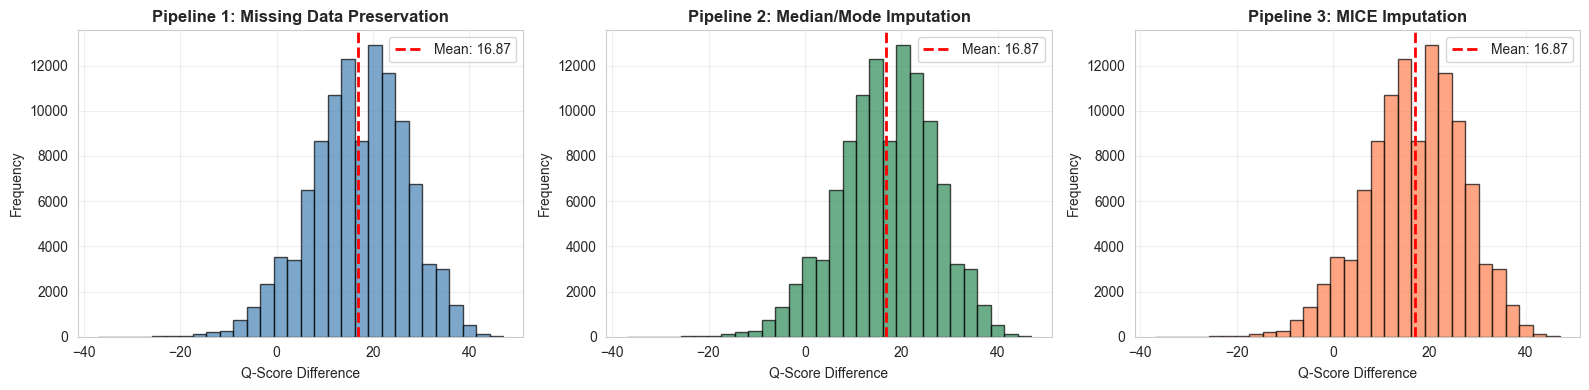

✓ Target distributions visualized


In [66]:
# Visualize target variable distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pipeline 1
axes[0].hist(y_train_p1, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Pipeline 1: Missing Data Preservation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Q-Score Difference')
axes[0].set_ylabel('Frequency')
axes[0].axvline(y_train_p1.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_train_p1.mean():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pipeline 2
axes[1].hist(y_train_p2, bins=30, color='seagreen', alpha=0.7, edgecolor='black')
axes[1].set_title('Pipeline 2: Median/Mode Imputation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Q-Score Difference')
axes[1].set_ylabel('Frequency')
axes[1].axvline(y_train_p2.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_train_p2.mean():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Pipeline 3
axes[2].hist(y_train_p3, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[2].set_title('Pipeline 3: MICE Imputation', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Q-Score Difference')
axes[2].set_ylabel('Frequency')
axes[2].axvline(y_train_p3.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_train_p3.mean():.2f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Target distributions visualized")

## 2. Missing Values Analysis

In [67]:
# Missing values by pipeline
print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_p1 = X_train_p1.isnull().sum()
missing_p2 = X_train_p2.isnull().sum()
missing_p3 = X_train_p3.isnull().sum()

total_missing_p1 = missing_p1.sum()
total_missing_p2 = missing_p2.sum()
total_missing_p3 = missing_p3.sum()

print(f"\nTotal missing values:")
print(f"  Pipeline 1: {total_missing_p1:,}")
print(f"  Pipeline 2: {total_missing_p2:,}")
print(f"  Pipeline 3: {total_missing_p3:,}")

print(f"\nMissing percentage:")
print(f"  Pipeline 1: {100 * total_missing_p1 / (X_train_p1.shape[0] * X_train_p1.shape[1]):.2f}%")
print(f"  Pipeline 2: {100 * total_missing_p2 / (X_train_p2.shape[0] * X_train_p2.shape[1]):.2f}%")
print(f"  Pipeline 3: {100 * total_missing_p3 / (X_train_p3.shape[0] * X_train_p3.shape[1]):.2f}%")

# Features with missing values in Pipeline 1
cols_with_missing_p1 = missing_p1[missing_p1 > 0].sort_values(ascending=False)
print(f"\nFeatures with missing values in Pipeline 1: {len(cols_with_missing_p1)}")
if len(cols_with_missing_p1) > 0:
    print("\nTop 10 features with most missing values:")
    for col, count in cols_with_missing_p1.head(10).items():
        pct = 100 * count / len(X_train_p1)
        print(f"  {col:50s} {count:5d} ({pct:5.2f}%)")

MISSING VALUES ANALYSIS

Total missing values:
  Pipeline 1: 5,661
  Pipeline 2: 0
  Pipeline 3: 0

Missing percentage:
  Pipeline 1: 0.12%
  Pipeline 2: 0.00%
  Pipeline 3: 0.00%

Features with missing values in Pipeline 1: 1

Top 10 features with most missing values:
  Pre-Op Q EQ5D Index                                 5661 ( 5.24%)


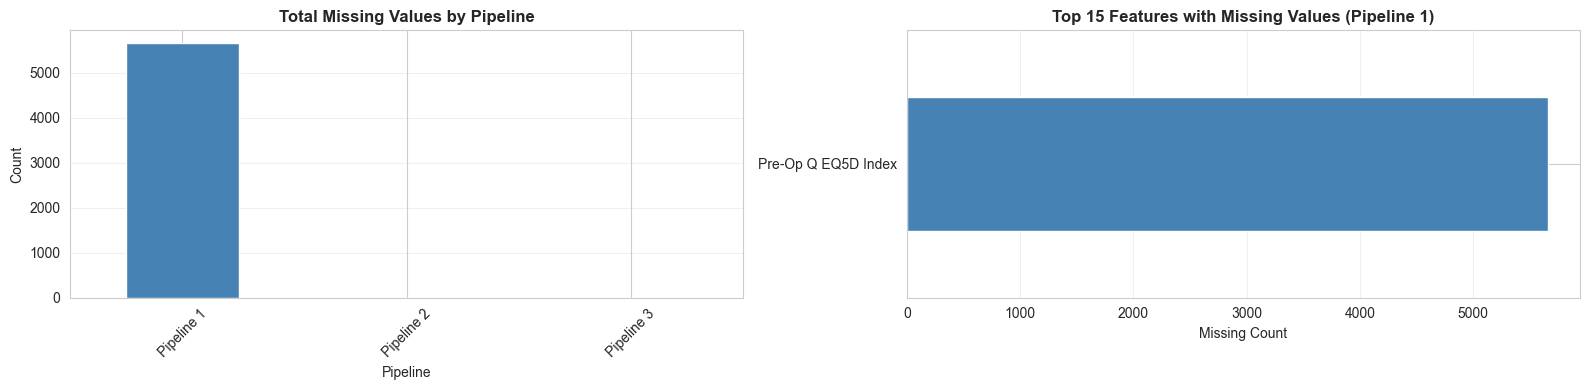

✓ Missingness visualized


In [68]:
# Visualize missingness pattern
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Missing counts by pipeline
missing_summary = pd.DataFrame({
    'Pipeline 1': [total_missing_p1],
    'Pipeline 2': [total_missing_p2],
    'Pipeline 3': [total_missing_p3]
})

missing_summary.T.plot(kind='bar', ax=axes[0], legend=False, color=['steelblue'])
axes[0].set_title('Total Missing Values by Pipeline', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Pipeline')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Features with missing values in Pipeline 1
if len(cols_with_missing_p1) > 0:
    cols_with_missing_p1.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Top 15 Features with Missing Values (Pipeline 1)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Missing Count')
    axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Missingness visualized")

## 3. Feature Type Distribution

In [69]:
# Analyze feature types
def analyze_feature_types(df, name):
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"\n{name}:")
    print(f"  Numeric features: {len(numeric)}")
    print(f"  Categorical features: {len(categorical)}")
    print(f"  Total features: {len(numeric) + len(categorical)}")
    
    return numeric, categorical

print("="*70)
print("FEATURE TYPE ANALYSIS")
print("="*70)

num_p1, cat_p1 = analyze_feature_types(X_train_p1, "Pipeline 1")
num_p2, cat_p2 = analyze_feature_types(X_train_p2, "Pipeline 2")
num_p3, cat_p3 = analyze_feature_types(X_train_p3, "Pipeline 3")

FEATURE TYPE ANALYSIS

Pipeline 1:
  Numeric features: 39
  Categorical features: 6
  Total features: 45

Pipeline 2:
  Numeric features: 44
  Categorical features: 6
  Total features: 50

Pipeline 3:
  Numeric features: 44
  Categorical features: 6
  Total features: 50


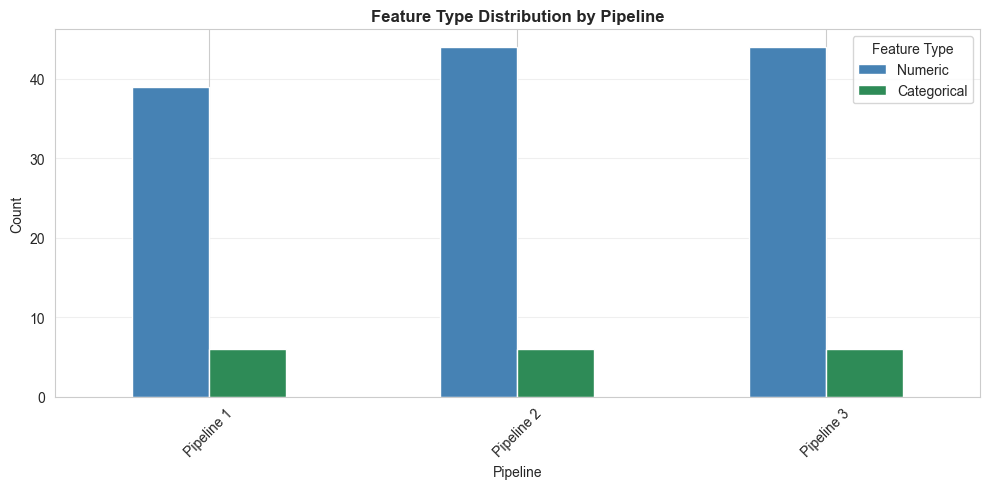

✓ Feature types visualized


In [70]:
# Visualize feature type distribution
feature_types = pd.DataFrame({
    'Numeric': [len(num_p1), len(num_p2), len(num_p3)],
    'Categorical': [len(cat_p1), len(cat_p2), len(cat_p3)]
}, index=['Pipeline 1', 'Pipeline 2', 'Pipeline 3'])

fig, ax = plt.subplots(figsize=(10, 5))
feature_types.plot(kind='bar', ax=ax, color=['steelblue', 'seagreen'])
ax.set_title('Feature Type Distribution by Pipeline', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Pipeline')
ax.legend(title='Feature Type')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Feature types visualized")

## 4. Numeric Features Summary

In [71]:
# Summary statistics for numeric features
print("="*70)
print("NUMERIC FEATURES SUMMARY STATISTICS")
print("="*70)

print(f"\nPipeline 1 - Top 10 features by standard deviation:")
numeric_p1 = X_train_p1.select_dtypes(include=[np.number])
print(numeric_p1.describe().loc['std'].sort_values(ascending=False).head(10))

print(f"\nPipeline 2 - Top 10 features by standard deviation:")
numeric_p2 = X_train_p2.select_dtypes(include=[np.number])
print(numeric_p2.describe().loc['std'].sort_values(ascending=False).head(10))

print(f"\nPipeline 3 - Top 10 features by standard deviation:")
numeric_p3 = X_train_p3.select_dtypes(include=[np.number])
print(numeric_p3.describe().loc['std'].sort_values(ascending=False).head(10))

NUMERIC FEATURES SUMMARY STATISTICS

Pipeline 1 - Top 10 features by standard deviation:
Pre-Op Q EQ5D Index Profile             13767.129811
Pre-Op Q EQ VAS                           269.289182
Pre-Op Q Disability                         1.582541
Pre-Op Q Anxiety                            1.523779
Pre-Op Q Self-Care                          1.413340
Pre-Op Q Discomfort                         1.374466
Pre-Op Q Activity                           1.299366
Pre-Op Q Mobility                           1.240780
Knee Replacement Pre-Op Q Shopping          1.206352
Knee Replacement Pre-Op Q Confidence        1.175763
Name: std, dtype: float64

Pipeline 2 - Top 10 features by standard deviation:
Pre-Op Q EQ5D Index Profile             13767.129811
Pre-Op Q EQ VAS                           269.289182
Pre-Op Q Disability                         1.582541
Pre-Op Q Anxiety                            1.523779
Pre-Op Q Self-Care                          1.413340
Pre-Op Q Discomfort                  

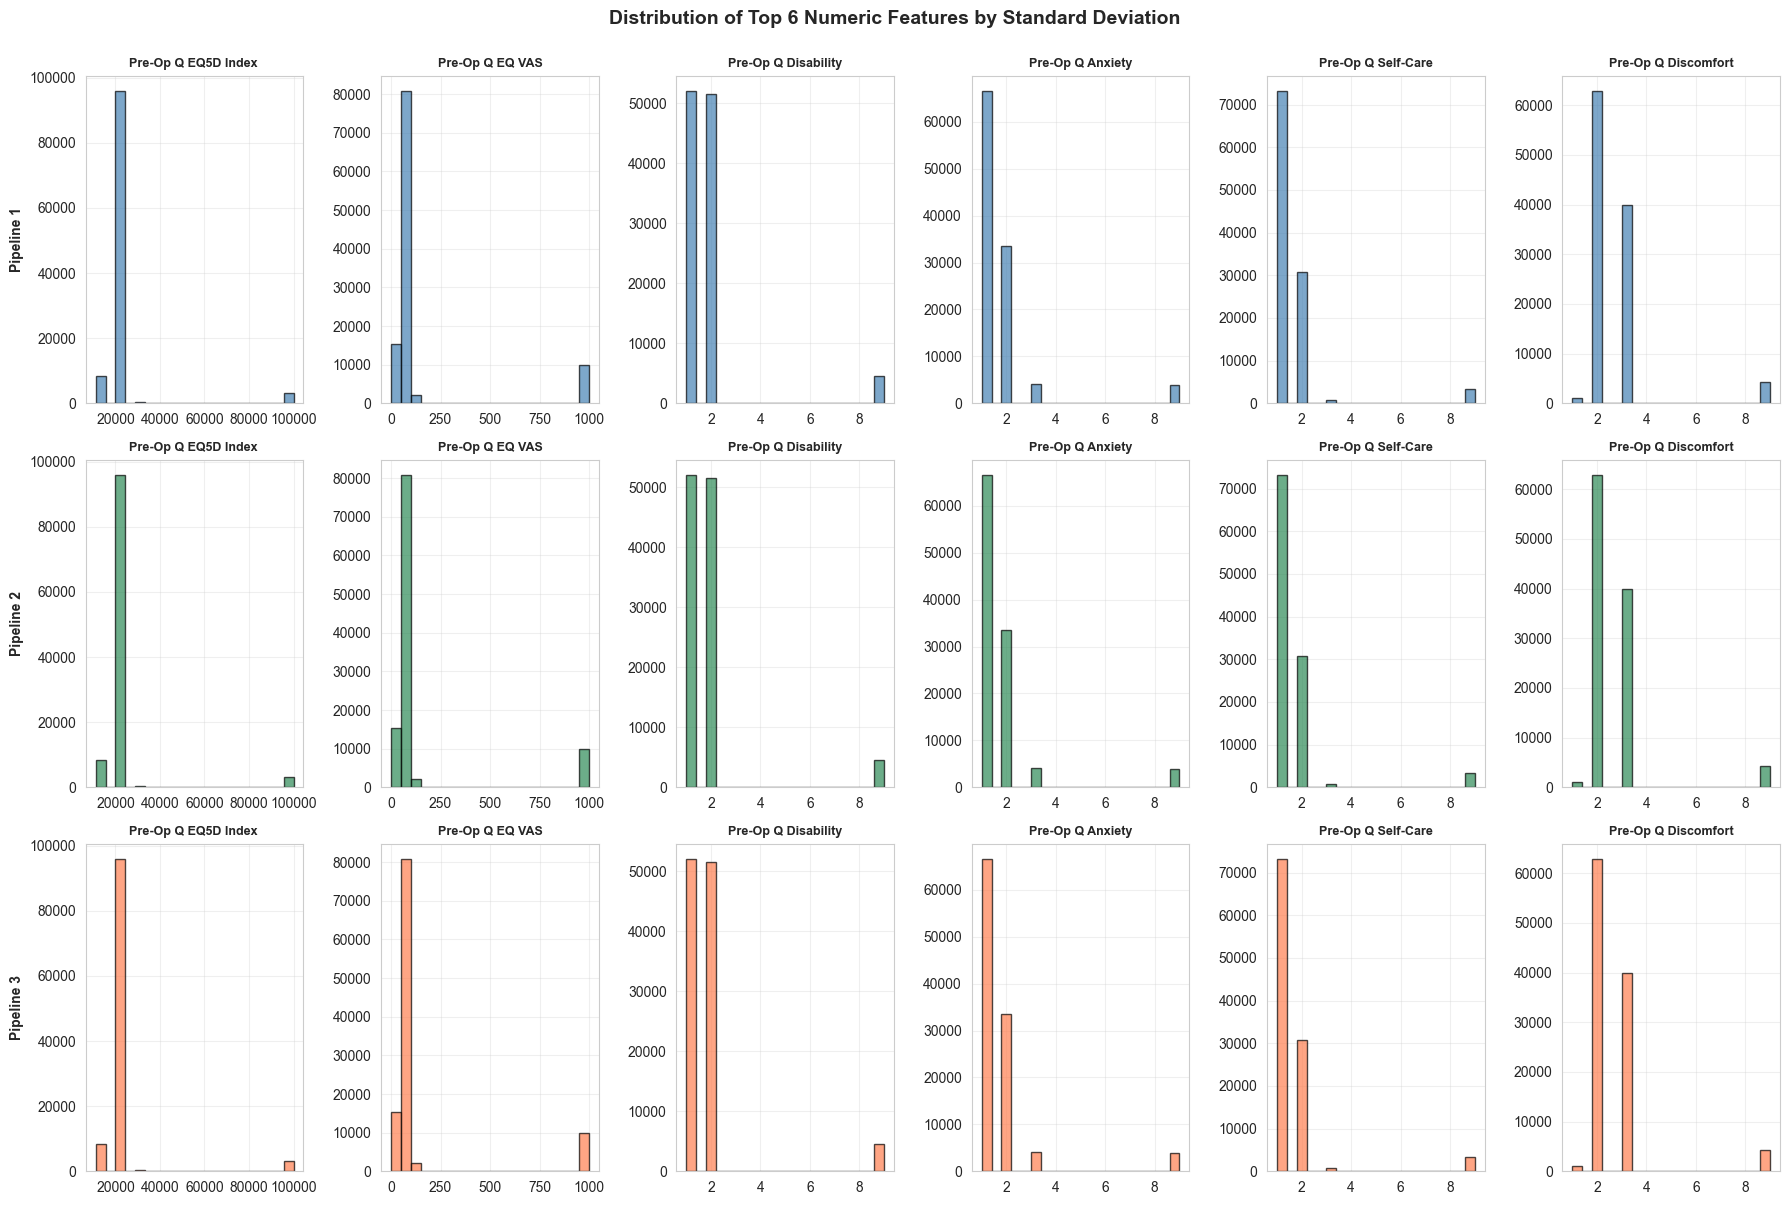

✓ Numeric feature distributions visualized


In [72]:
# Visualize numeric feature distributions (top 6 by variance)
fig, axes = plt.subplots(3, 6, figsize=(18, 12))

# Get top 6 numeric features by standard deviation for each pipeline
top_features_p1 = numeric_p1.std().sort_values(ascending=False).head(6).index.tolist()
top_features_p2 = numeric_p2.std().sort_values(ascending=False).head(6).index.tolist()
top_features_p3 = numeric_p3.std().sort_values(ascending=False).head(6).index.tolist()

# Pipeline 1
for idx, col in enumerate(top_features_p1):
    axes[0, idx].hist(X_train_p1[col].dropna(), bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(col[:20], fontsize=9, fontweight='bold')
    axes[0, idx].grid(True, alpha=0.3)

# Pipeline 2
for idx, col in enumerate(top_features_p2):
    axes[1, idx].hist(X_train_p2[col].dropna(), bins=20, color='seagreen', alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(col[:20], fontsize=9, fontweight='bold')
    axes[1, idx].grid(True, alpha=0.3)

# Pipeline 3
for idx, col in enumerate(top_features_p3):
    axes[2, idx].hist(X_train_p3[col].dropna(), bins=20, color='coral', alpha=0.7, edgecolor='black')
    axes[2, idx].set_title(col[:20], fontsize=9, fontweight='bold')
    axes[2, idx].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Pipeline 1', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Pipeline 2', fontsize=10, fontweight='bold')
axes[2, 0].set_ylabel('Pipeline 3', fontsize=10, fontweight='bold')

plt.suptitle('Distribution of Top 6 Numeric Features by Standard Deviation', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Numeric feature distributions visualized")

## 5. Missingness Indicators (Pipelines 2 & 3)

In [73]:
# Identify and analyze missingness indicator columns
print("="*70)
print("MISSINGNESS INDICATOR COLUMNS")
print("="*70)

missing_indicator_cols_p2 = [col for col in X_train_p2.columns if col.endswith('_is_missing')]
missing_indicator_cols_p3 = [col for col in X_train_p3.columns if col.endswith('_is_missing')]

print(f"\nPipeline 2:")
print(f"  Missingness indicator columns: {len(missing_indicator_cols_p2)}")
if len(missing_indicator_cols_p2) > 0:
    print(f"\n  Indicators:")
    for col in sorted(missing_indicator_cols_p2):
        count = X_train_p2[col].sum()
        pct = 100 * count / len(X_train_p2)
        print(f"    {col:50s} {count:5.0f} missing ({pct:5.2f}%)")

print(f"\nPipeline 3:")
print(f"  Missingness indicator columns: {len(missing_indicator_cols_p3)}")
if len(missing_indicator_cols_p3) > 0:
    print(f"\n  Indicators:")
    for col in sorted(missing_indicator_cols_p3):
        count = X_train_p3[col].sum()
        pct = 100 * count / len(X_train_p3)
        print(f"    {col:50s} {count:5.0f} missing ({pct:5.2f}%)")

MISSINGNESS INDICATOR COLUMNS

Pipeline 2:
  Missingness indicator columns: 5

  Indicators:
    Knee Replacement EQ 5D Index Post-Op Q Predicted_is_missing 10562 missing ( 9.78%)
    Knee Replacement EQ VAS_Post-Op Q Predicted_is_missing 14805 missing (13.70%)
    Knee Replacement OKS Post-Op Q Predicted_is_missing   965 missing ( 0.89%)
    Post-Op Q EQ5D Index_is_missing                     4408 missing ( 4.08%)
    Pre-Op Q EQ5D Index_is_missing                      5661 missing ( 5.24%)

Pipeline 3:
  Missingness indicator columns: 5

  Indicators:
    Knee Replacement EQ 5D Index Post-Op Q Predicted_is_missing 10562 missing ( 9.78%)
    Knee Replacement EQ VAS_Post-Op Q Predicted_is_missing 14805 missing (13.70%)
    Knee Replacement OKS Post-Op Q Predicted_is_missing   965 missing ( 0.89%)
    Post-Op Q EQ5D Index_is_missing                     4408 missing ( 4.08%)
    Pre-Op Q EQ5D Index_is_missing                      5661 missing ( 5.24%)


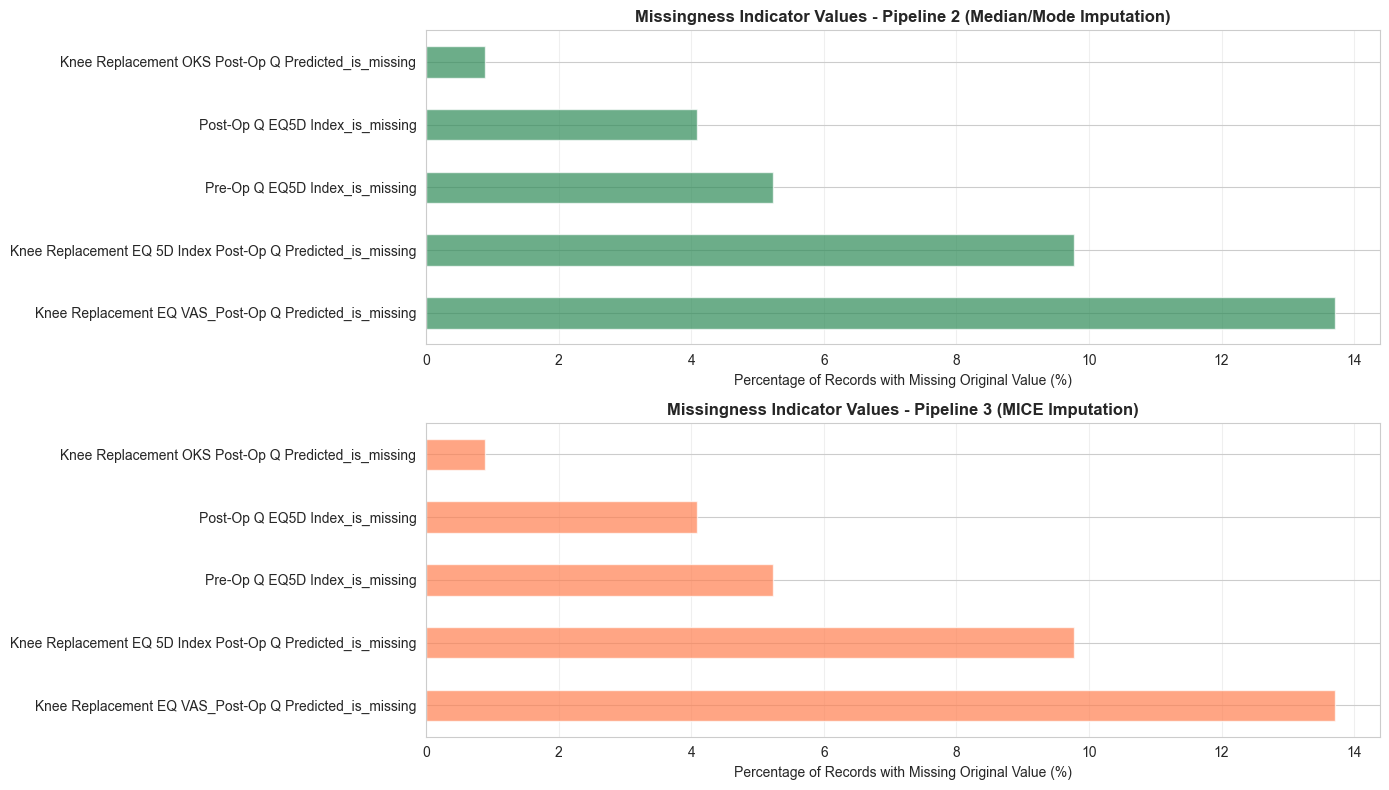

✓ Missingness indicators visualized


In [74]:
# Visualize missingness indicator patterns
if len(missing_indicator_cols_p2) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Pipeline 2
    missing_pct_p2 = (X_train_p2[missing_indicator_cols_p2].sum() / len(X_train_p2) * 100).sort_values(ascending=False)
    missing_pct_p2.plot(kind='barh', ax=axes[0], color='seagreen', alpha=0.7)
    axes[0].set_title('Missingness Indicator Values - Pipeline 2 (Median/Mode Imputation)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Percentage of Records with Missing Original Value (%)')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Pipeline 3
    missing_pct_p3 = (X_train_p3[missing_indicator_cols_p3].sum() / len(X_train_p3) * 100).sort_values(ascending=False)
    missing_pct_p3.plot(kind='barh', ax=axes[1], color='coral', alpha=0.7)
    axes[1].set_title('Missingness Indicator Values - Pipeline 3 (MICE Imputation)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Percentage of Records with Missing Original Value (%)')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Missingness indicators visualized")
else:
    print("No missingness indicator columns found")

## 6. Feature Correlation with Target

In [75]:
# Calculate correlations with target for numeric features
print("="*70)
print("CORRELATION WITH TARGET VARIABLE")
print("="*70)

# Pipeline 2 (has missingness indicators)
numeric_cols_p2 = X_train_p2.select_dtypes(include=[np.number]).columns.tolist()
correlations_p2 = [X_train_p2[col].corr(y_train_p2) for col in numeric_cols_p2]
corr_series_p2 = pd.Series(correlations_p2, index=numeric_cols_p2).dropna().sort_values(key=abs, ascending=False)

print(f"\nPipeline 2 - Top 15 features with highest correlation (absolute value):")
print(corr_series_p2.head(15))

# Pipeline 3 (has missingness indicators)
numeric_cols_p3 = X_train_p3.select_dtypes(include=[np.number]).columns.tolist()
correlations_p3 = [X_train_p3[col].corr(y_train_p3) for col in numeric_cols_p3]
corr_series_p3 = pd.Series(correlations_p3, index=numeric_cols_p3).dropna().sort_values(key=abs, ascending=False)

print(f"\nPipeline 3 - Top 15 features with highest correlation (absolute value):")
print(corr_series_p3.head(15))

CORRELATION WITH TARGET VARIABLE

Pipeline 2 - Top 15 features with highest correlation (absolute value):
Knee Replacement Pre-Op Q Limping      -0.368364
Knee Replacement Pre-Op Q Work         -0.351087
Knee Replacement Pre-Op Q Standing     -0.329967
Knee Replacement Pre-Op Q Pain         -0.323111
Knee Replacement Pre-Op Q Stairs       -0.306527
Knee Replacement Pre-Op Q Shopping     -0.305262
Knee Replacement Pre-Op Q Walking      -0.294094
Knee Replacement Pre-Op Q Confidence   -0.294078
Knee Replacement Pre-Op Q Transport    -0.279235
Knee Replacement Pre-Op Q Night Pain   -0.262292
Pre-Op Q EQ5D Index                    -0.256579
Knee Replacement Pre-Op Q Kneeling     -0.240945
Knee Replacement Pre-Op Q Washing      -0.217627
Pre-Op Q Discomfort                     0.093119
Revision Flag                          -0.078426
dtype: float64

Pipeline 3 - Top 15 features with highest correlation (absolute value):
Knee Replacement Pre-Op Q Limping      -0.368364
Knee Replacement Pre-O

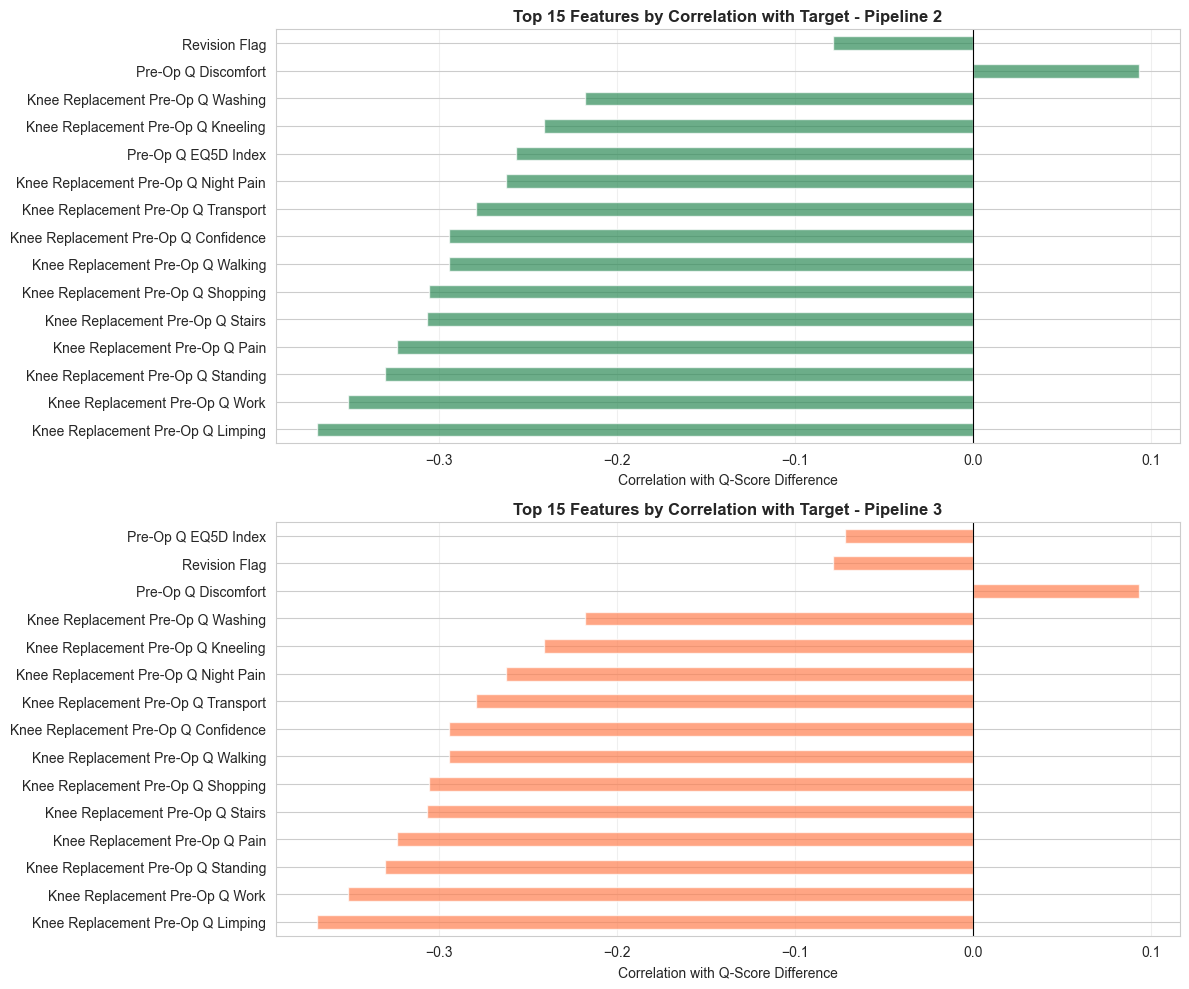

✓ Target correlations visualized


In [76]:
# Visualize correlations with target
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Pipeline 2
corr_series_p2.head(15).plot(kind='barh', ax=axes[0], color='seagreen', alpha=0.7)
axes[0].set_title('Top 15 Features by Correlation with Target - Pipeline 2', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation with Q-Score Difference')
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Pipeline 3
corr_series_p3.head(15).plot(kind='barh', ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('Top 15 Features by Correlation with Target - Pipeline 3', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation with Q-Score Difference')
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Target correlations visualized")

## 7. Data Completeness Comparison

In [77]:
# Create a comprehensive comparison table
print("="*70)
print("COMPREHENSIVE DATASET COMPARISON")
print("="*70)

comparison_data = {
    'Metric': [
        'Train Samples',
        'Features',
        'Numeric Features',
        'Categorical Features',
        'Missingness Indicators',
        'Total Missing Values',
        'Missing %',
        'Target Mean',
        'Target Std',
        'Target Min',
        'Target Max'
    ],
    'Pipeline 1': [
        X_train_p1.shape[0],
        X_train_p1.shape[1],
        len(num_p1),
        len(cat_p1),
        0,
        total_missing_p1,
        f"{100 * total_missing_p1 / (X_train_p1.shape[0] * X_train_p1.shape[1]):.2f}%",
        f"{y_train_p1.mean():.2f}",
        f"{y_train_p1.std():.2f}",
        f"{y_train_p1.min():.2f}",
        f"{y_train_p1.max():.2f}"
    ],
    'Pipeline 2': [
        X_train_p2.shape[0],
        X_train_p2.shape[1],
        len(num_p2),
        len(cat_p2),
        len(missing_indicator_cols_p2),
        total_missing_p2,
        f"{100 * total_missing_p2 / (X_train_p2.shape[0] * X_train_p2.shape[1]):.2f}%",
        f"{y_train_p2.mean():.2f}",
        f"{y_train_p2.std():.2f}",
        f"{y_train_p2.min():.2f}",
        f"{y_train_p2.max():.2f}"
    ],
    'Pipeline 3': [
        X_train_p3.shape[0],
        X_train_p3.shape[1],
        len(num_p3),
        len(cat_p3),
        len(missing_indicator_cols_p3),
        total_missing_p3,
        f"{100 * total_missing_p3 / (X_train_p3.shape[0] * X_train_p3.shape[1]):.2f}%",
        f"{y_train_p3.mean():.2f}",
        f"{y_train_p3.std():.2f}",
        f"{y_train_p3.min():.2f}",
        f"{y_train_p3.max():.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

COMPREHENSIVE DATASET COMPARISON

                Metric Pipeline 1 Pipeline 2 Pipeline 3
         Train Samples     108040     108040     108040
              Features         45         50         50
      Numeric Features         39         44         44
  Categorical Features          6          6          6
Missingness Indicators          0          5          5
  Total Missing Values       5661          0          0
             Missing %      0.12%      0.00%      0.00%
           Target Mean      16.87      16.87      16.87
            Target Std       9.87       9.87       9.87
            Target Min     -37.00     -37.00     -37.00
            Target Max      47.00      47.00      47.00


## 8. Summary Insights

In [78]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"""
1. TARGET VARIABLE (Q-Score Difference):
   - All three pipelines use the same target variable
   - Target represents patient improvement: Post-Op Q-Score - Pre-Op Q-Score
   - Mean improvement across pipelines: {y_train_p2.mean():.2f}
   - Standard deviation: {y_train_p2.std():.2f}

2. MISSING DATA HANDLING:
   - Pipeline 1: Preserves {total_missing_p1:,} missing values
   - Pipeline 2: Imputes all missing values + adds {len(missing_indicator_cols_p2)} indicators
   - Pipeline 3: Imputes using MICE + adds {len(missing_indicator_cols_p3)} indicators

3. FEATURE COMPOSITION:
   - All pipelines have {X_train_p2.shape[1]} total features
   - Numeric features: {len(num_p2)}
   - Categorical features: {len(cat_p2)}
   - Missingness indicators (P2 & P3): {len(missing_indicator_cols_p2)}

4. DATA QUALITY:
   - Pipeline 1: Best for tree-based models (preserves missing patterns)
   - Pipeline 2: Simpler imputation, good for interpretability
   - Pipeline 3: MICE imputation, captures feature relationships

5. MISSINGNESS INDICATORS:
   - Columns with >2% missingness get binary indicator columns
   - Indicators in P2 & P3 preserve information about original missing patterns
   - Useful for capturing "missingness as informative" patterns
""")


KEY INSIGHTS

1. TARGET VARIABLE (Q-Score Difference):
   - All three pipelines use the same target variable
   - Target represents patient improvement: Post-Op Q-Score - Pre-Op Q-Score
   - Mean improvement across pipelines: 16.87
   - Standard deviation: 9.87

2. MISSING DATA HANDLING:
   - Pipeline 1: Preserves 5,661 missing values
   - Pipeline 2: Imputes all missing values + adds 5 indicators
   - Pipeline 3: Imputes using MICE + adds 5 indicators

3. FEATURE COMPOSITION:
   - All pipelines have 50 total features
   - Numeric features: 44
   - Categorical features: 6
   - Missingness indicators (P2 & P3): 5

4. DATA QUALITY:
   - Pipeline 1: Best for tree-based models (preserves missing patterns)
   - Pipeline 2: Simpler imputation, good for interpretability
   - Pipeline 3: MICE imputation, captures feature relationships

5. MISSINGNESS INDICATORS:
   - Columns with >2% missingness get binary indicator columns
   - Indicators in P2 & P3 preserve information about original missin